# EXPL_04 — Local Historical Prediction Explanations

This notebook explains one historical model-compatible observation before
moving to a live operational explanation.

Change `FSA`, `HORIZON`, and `FORECAST_ORIGIN` only to timestamps that exist in
the historical feature dataset.


In [1]:
# Import libraries
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "explainability.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/explainability.yaml')

In [3]:
# Import modules for generating explainability
from src.ontario_peak_risk.explainability.common import (
    load_explainability_config,
    ensure_phase_directories,
    load_final_metadata,
)

In [4]:
# Load parameters
config, project_root = load_explainability_config(CONFIG_PATH)
phase_paths = ensure_phase_directories(config, project_root)
metadata = load_final_metadata(config, project_root)

print("Project root:", project_root)
print("RF:", metadata["rf"]["algorithm"], "| horizons:", metadata["rf"]["horizons"])
print("XGB:", metadata["xgb"]["algorithm"], "| horizons:", metadata["xgb"]["horizons"])
print("Explainability output:", phase_paths["outputs_dir"])


Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
RF: RandomForestRegressor | horizons: 24
XGB: XGBoostClassifier | horizons: 24
Explainability output: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\explainability


In [5]:
from src.ontario_peak_risk.explainability.data import (
    load_historical_feature_dataset,
    build_model_features,
)
from src.ontario_peak_risk.explainability.model_access import load_horizon_pipeline
from src.ontario_peak_risk.explainability.shap_analysis import compute_tree_shap
from src.ontario_peak_risk.explainability.local import (
    prediction_value,
    local_contribution_table,
    human_readable_local_summary,
)
from src.ontario_peak_risk.explainability.plotting import local_contribution_plot

In [6]:

feature_dataset = load_historical_feature_dataset(config, project_root)

FSA = "M9W"
FORECAST_ORIGIN = pd.Timestamp("2025-07-23 23:00:00")
HORIZON = 18

origins = pd.DataFrame({
    "fsa": [FSA],
    "forecast_origin": [FORECAST_ORIGIN],
})
TARGET_TIMESTAMP = FORECAST_ORIGIN + pd.Timedelta(hours=HORIZON)

print("FSA:", FSA)
print("Forecast origin:", FORECAST_ORIGIN)
print("Target:", TARGET_TIMESTAMP)
print("Horizon:", HORIZON)


FSA: M9W
Forecast origin: 2025-07-23 23:00:00
Target: 2025-07-24 17:00:00
Horizon: 18



Demand forecast explanation — M9W, 2025-07-24 17:00: 27,507.8 kWh

- target_lag_24h = 24513.699999999997: increases forecast (SHAP=+12394.9917)
- target_lag_48h = 20248.8: increases forecast (SHAP=+2113.7882)
- origin_rolling_std_24h = 5485.158704002664: increases forecast (SHAP=+1046.1519)
- target_lag_168h = 21929.3: increases forecast (SHAP=+1002.1635)
- origin__Stn Press (kPa) = 99.78: increases forecast (SHAP=+685.0773)
- origin_rolling_mean_24h = 17679.3875: increases forecast (SHAP=+369.8502)
- origin__reported_premise_count = 11173: increases forecast (SHAP=+291.1463)
- origin_rolling_mean_168h = 16919.842857142856: increases forecast (SHAP=+199.8788)
- fsa = M9W: increases forecast (SHAP=+148.7591)
- origin__Rel Hum (%) = 82.0: increases forecast (SHAP=+134.1475)


,task,horizon,feature,feature_value,shap_contribution,abs_contribution,direction
0,rf,18,target_lag_24h,24513.7,12394.991697,12394.991697,increases forecast
1,rf,18,target_lag_48h,20248.8,2113.788165,2113.788165,increases forecast
2,rf,18,origin_rolling_std_24h,5485.158704,1046.151918,1046.151918,increases forecast
3,rf,18,target_lag_168h,21929.3,1002.163537,1002.163537,increases forecast
4,rf,18,origin__Stn Press (kPa),99.78,685.077290,685.077290,increases forecast
5,rf,18,origin_rolling_mean_24h,17679.3875,369.850229,369.850229,increases forecast
6,rf,18,origin__reported_premise_count,11173,291.146314,291.146314,increases forecast
7,rf,18,origin_rolling_mean_168h,16919.842857,199.878828,199.878828,increases forecast
8,rf,18,fsa,M9W,148.759116,148.759116,increases forecast
9,rf,18,origin__Rel Hum (%),82.0,134.147541,134.147541,increases forecast


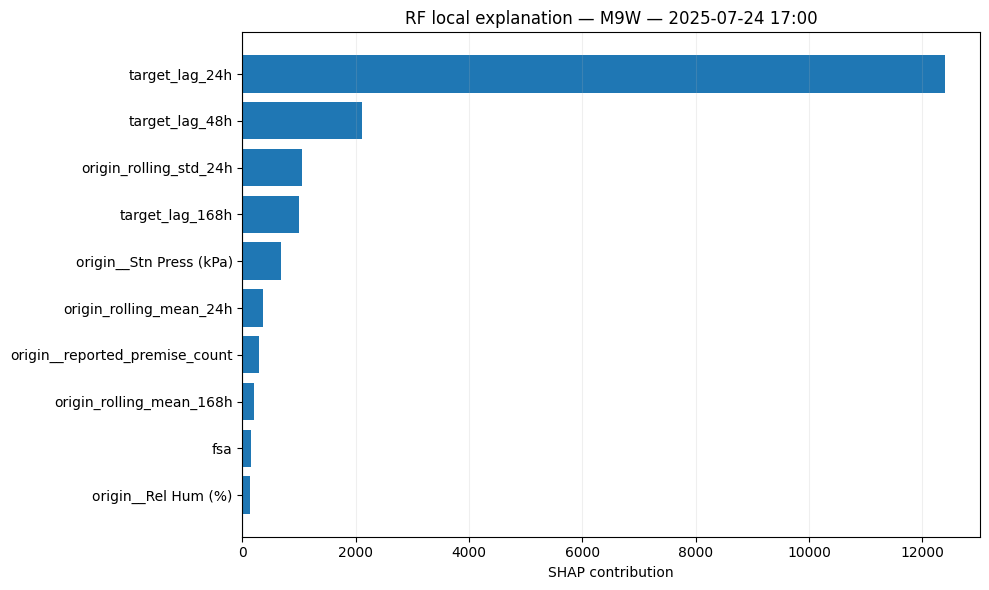


Peak-Risk explanation — M9W, 2025-07-24 17:00: score=0.945

- target_lag_24h = 24513.699999999997: increases risk score (SHAP=+3.1725)
- fsa = M9W: decreases risk score (SHAP=-0.9925)
- origin_rolling_std_24h = 5557.375755772668: increases risk score (SHAP=+0.9267)
- target_month_cos = -1.0: decreases risk score (SHAP=-0.8364)
- target_hour = 17: increases risk score (SHAP=+0.5447)
- target_hour_sin = -0.9659258262890683: increases risk score (SHAP=+0.5437)
- target_weekday_cos = -0.900968867902419: decreases risk score (SHAP=-0.3264)
- origin_rolling_mean_168h = 16949.061904761907: decreases risk score (SHAP=-0.2584)
- origin__Temp (°C) = 20.8: decreases risk score (SHAP=-0.2222)
- target_season = Summer: decreases risk score (SHAP=-0.2039)

Note: tree SHAP contributions are interpreted on the model's native/raw output scale unless probability-output SHAP is explicitly configured. The displayed Peak-Risk probability is reported separately.


,task,horizon,feature,feature_value,shap_contribution,abs_contribution,direction
0,xgb,18,target_lag_24h,24513.7,3.172537,3.172537,increases risk score
1,xgb,18,fsa,M9W,-0.992464,0.992464,decreases risk score
2,xgb,18,origin_rolling_std_24h,5557.375756,0.926689,0.926689,increases risk score
3,xgb,18,target_month_cos,-1.0,-0.836395,0.836395,decreases risk score
4,xgb,18,target_hour,17,0.544708,0.544708,increases risk score
5,xgb,18,target_hour_sin,-0.965926,0.543655,0.543655,increases risk score
6,xgb,18,target_weekday_cos,-0.900969,-0.326367,0.326367,decreases risk score
7,xgb,18,origin_rolling_mean_168h,16949.061905,-0.258432,0.258432,decreases risk score
8,xgb,18,origin__Temp (°C),20.8,-0.222152,0.222152,decreases risk score
9,xgb,18,target_season,Summer,-0.203893,0.203893,decreases risk score


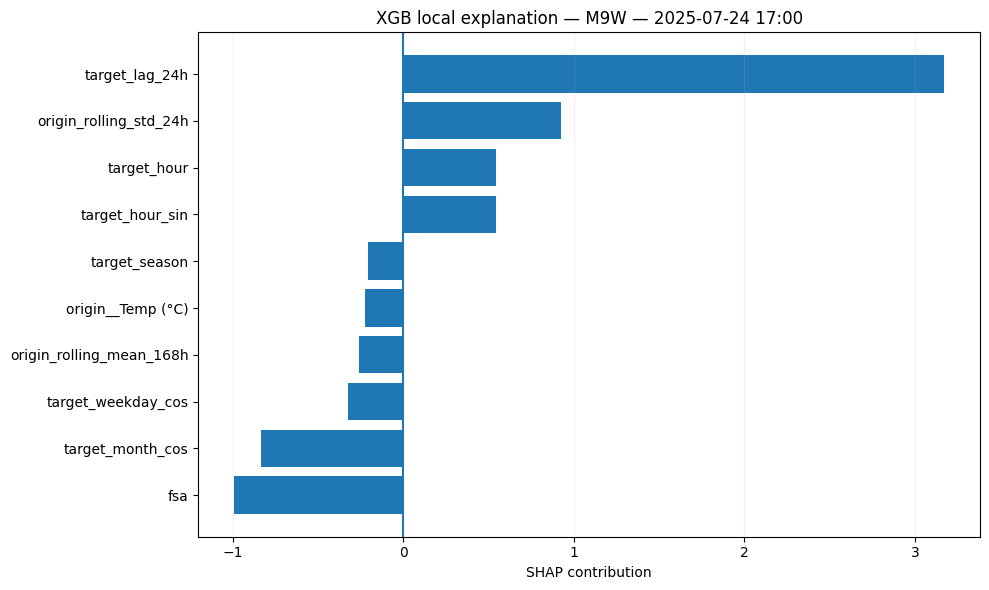

In [8]:
local_results = {}

for task in ["rf", "xgb"]:
    task_meta = metadata[task]
    frame = build_model_features(
        task,
        origins,
        feature_dataset,
        HORIZON,
        task_meta,
    )
    features = (
        task_meta["numeric_features"]
        + task_meta["categorical_features"]
    )
    X = frame[features].copy()

    if len(X) != 1:
        raise ValueError(
            f"No complete local explanation row for {task}. "
            "Choose another historical origin."
        )

    pipeline = load_horizon_pipeline(
        task, HORIZON, config, project_root
    )
    prediction = prediction_value(pipeline, X, task)
    shap_result = compute_tree_shap(
        pipeline,
        X,
        task_meta,
        config,
        task=task,
        horizon=HORIZON,
    )
    table = local_contribution_table(
        X,
        shap_result,
        task=task,
        horizon=HORIZON,
        top_n=config["analysis"]["local_top_n"],
    )
    text = human_readable_local_summary(
        table,
        prediction=prediction,
        task=task,
        fsa=FSA,
        target_timestamp=TARGET_TIMESTAMP,
    )

    local_results[task] = {
        "prediction": prediction,
        "table": table,
        "text": text,
    }

    print("\n" + text)
    display(table)

    title = (
        f"{task.upper()} local explanation — "
        f"{FSA} — {TARGET_TIMESTAMP:%Y-%m-%d %H:%M}"
    )
    local_contribution_plot(table, title=title)
    plt.show()

    del shap_result, pipeline, X, frame


For XGBoost, the displayed probability and the official alert threshold are
reported separately. SHAP explains the fitted classifier, not the business
choice of threshold.


In [9]:
print(
    "Official Peak-Risk threshold:",
    metadata["xgb"]["operational_threshold"],
)
print("EXPL_04 RESULT: COMPLETE")


Official Peak-Risk threshold: 0.06
EXPL_04 RESULT: COMPLETE


In [10]:
# ---------------------------------------------------------------
# Save EXPL_04 local explanation outputs
# ---------------------------------------------------------------

rf_table = local_results["rf"]["table"].copy()
xgb_table = local_results["xgb"]["table"].copy()

rf_table.to_csv(
    phase_paths["outputs_dir"] / "EXPL_04_RF_local_explanation.csv",
    index=False,
)

xgb_table.to_csv(
    phase_paths["outputs_dir"] / "EXPL_04_XGB_local_explanation.csv",
    index=False,
)

from src.ontario_peak_risk.explainability.reporting import write_local_report

summary_text = (
    f"Forecast origin: {FORECAST_ORIGIN}\n\n"
    f"FSA: {FSA}\n\n"
    f"Target: {TARGET_TIMESTAMP}\n\n"
    f"RF demand forecast: {local_results['rf']['prediction']:,.2f} kWh\n\n"
    f"XGB Peak-Risk probability: {local_results['xgb']['prediction']:.4f}\n\n"
    f"Official Peak-Risk threshold: "
    f"{metadata['xgb']['operational_threshold']:.2f}"
)

write_local_report(
    phase_paths["docs_dir"] / "EXPL_04_Local_Prediction_Explanation.md",
    rf_table,
    xgb_table,
    summary_text,
)

print("EXPL_04 outputs saved.")

EXPL_04 outputs saved.
